In [1]:
import numpy as np
import xarray as xr
import rioxarray
import rasterio
from rasterio.plot import show
from rasterio.transform import xy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


# replace with your file path
fp = "/home/madhulika.gurazada/paper2/Data/AEI2015.tif"

In [2]:
with rasterio.open(fp) as src:
    # How many bands?
    print("Band count:", src.count)
    # Which band indexes are available
    print("Indexes:", src.indexes)
    # Optional: descriptive names (if present)
    print("Descriptions:", src.descriptions)

    # Read all bands at once into a 3-D array (bands, rows, cols)
    all_data = src.read()
    print("All bands array shape:", all_data.shape)

    # Or loop through them one by one
    for b in src.indexes:
        band = src.read(b)
        print(f"Band {b}: shape={band.shape}, min={band.min()}, max={band.max()}")
        # You can also inspect metadata/tags per band:
        print("  Tags:", src.tags(b))


Band count: 1
Indexes: (1,)
Descriptions: (None,)
All bands array shape: (1, 2160, 4320)
Band 1: shape=(2160, 4320), min=0.0, max=8582.121
  Tags: {}


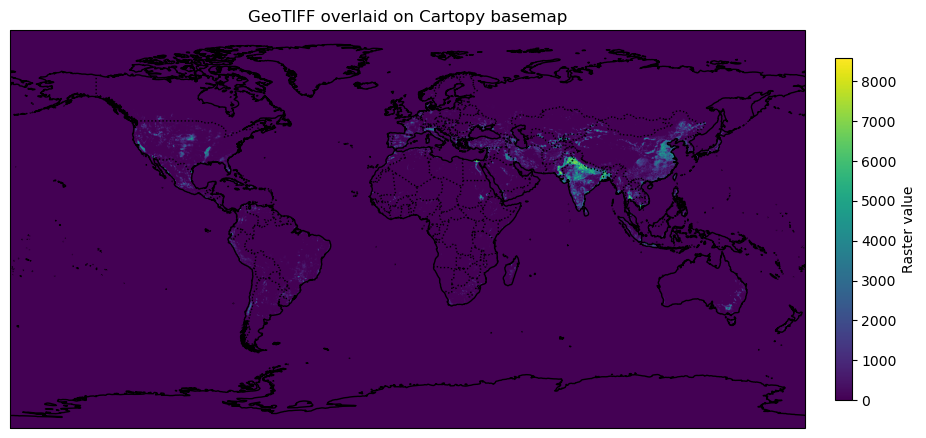

In [3]:
with rasterio.open(fp) as src:
    data = src.read(1)
    # grab the geographic bounds for correct placement
    left, bottom, right, top = src.bounds
    extent = [left, right, bottom, top]

fig, ax = plt.subplots(
    1, 1, figsize=(10, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# plot with imshow so we get a mappable back
im = ax.imshow(
    data,
    origin="upper",
    extent=extent,
    transform=ccrs.PlateCarree(),
    cmap="viridis"
)

# add map features
ax.add_feature(cfeature.COASTLINE.with_scale("50m"))
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":")
ax.set_title("GeoTIFF overlaid on Cartopy basemap")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# add a colorbar (your “legend”)
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    shrink=0.6,
    pad=0.03,
    label="Raster value"
)

plt.tight_layout()
plt.show()

In [4]:
# 1. Open the GeoTIFF (preserves CRS & transform)
da = rioxarray.open_rasterio("/home/madhulika.gurazada/paper2/Data/AEI2015.tif", masked=True)

# 2. If it’s single‐band, drop the extra 'band' dim
if "band" in da.dims and da.band.size == 1:
    da = da.squeeze("band", drop=True)

xres, yres = da.rio.resolution()
print(f"Pixel size: {xres} × {yres} (units of the CRS)")

# 3. Convert to a Dataset and give your variable a name
ds = da.to_dataset(name="irrigated_area")

# 4. (Optional) set CF‐compliant attrs
ds["irrigated_area"].attrs.update({
    "units": "ha",
    "long_name": "AEI2015"
})
ds.attrs.update({
    "title": "Converted from GeoTIFF",
    "source": "input.tif"
})

# 5. Write to NetCDF
ds.to_netcdf("AEI2015.nc")

Pixel size: 0.08333333333333333 × -0.08333333333333333 (units of the CRS)


In [5]:
import xarray as xr

# 1. Open the dataset
ds = xr.open_dataset("/home/madhulika.gurazada/paper2/Data/AEI2015.nc")


# 3. Pull out a variable (e.g. “my_var”) as a DataArray
aei2015 = ds["irrigated_area"]
# 2. Rename 'x' → 'longitude' and 'y' → 'latitude'
aei2015 = aei2015.rename({'x': 'longitude', 'y': 'latitude'})

# 3. Sort so longitude goes from -180 → 180 and latitude from -90 → 90
aei2015 = aei2015.sortby('longitude')
aei2015 = aei2015.sortby('latitude')

aei2015

<xarray.DataArray 'irrigated_area' (latitude: 2160, longitude: 4320)>
[9331200 values with dtype=float64]
Coordinates:
  * longitude  (longitude) float64 -180.0 -179.9 -179.8 ... 179.8 179.9 180.0
  * latitude   (latitude) float64 -89.96 -89.87 -89.79 ... 89.79 89.88 89.96
Attributes:
    AREA_OR_POINT:  Area
    units:          ha
    long_name:      AEI2015
    grid_mapping:   spatial_ref

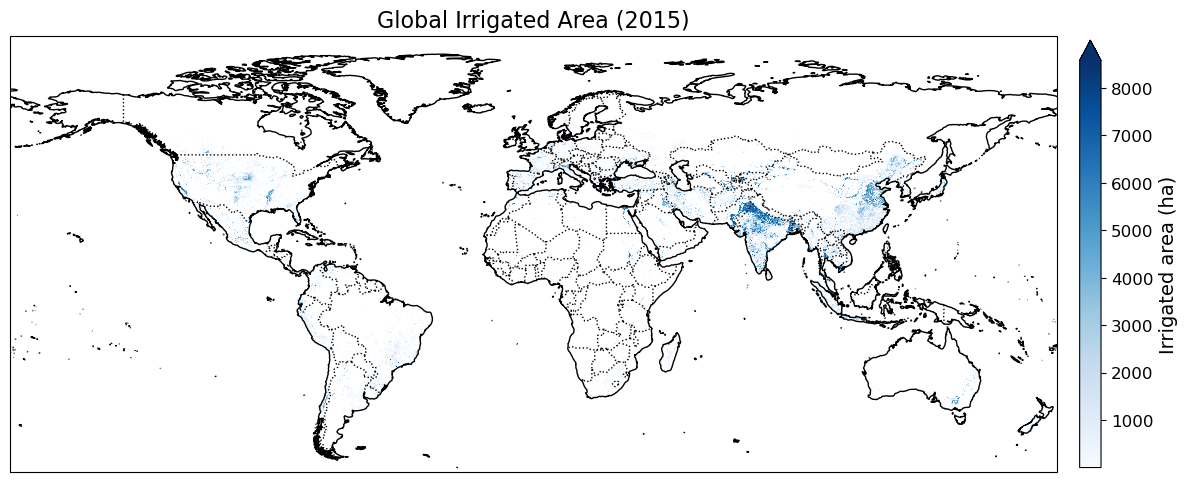

In [6]:
lat_min, lat_max = -60, 90
lon_min, lon_max = -182, 180

# Mask zero values
masked_aei = aei2015.where(aei2015 > 0)

# Custom colormap: map NaNs to white
cmap = plt.cm.Blues
new_cmap = mcolors.ListedColormap(['white'] + [cmap(i) for i in range(1, cmap.N)])

# Plot setup
fig, ax = plt.subplots(
    1, 1,
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Plotting
mesh = ax.pcolormesh(
    masked_aei["longitude"],
    masked_aei["latitude"],
    masked_aei,
    transform=ccrs.PlateCarree(),
    cmap=new_cmap,
    shading="auto"
)

# Features
ax.add_feature(cfeature.COASTLINE.with_scale("50m"))
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":")
ax.set_title("Global Irrigated Area (2015)", fontsize=16)
ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)
ax.tick_params(labelsize=12)

# Colorbar (adjusted)
cbar = fig.colorbar(
    mesh,
    ax=ax,
    orientation="vertical",
    pad=0.02,
    fraction=0.035,
    shrink=0.75, 
    extend='max'
)
cbar.set_label("Irrigated area (ha)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

In [7]:
# 2. Coarsen by 6×6 and sum (summing irrigated‐area within each 0.5° cell)
aei_coarse = aei2015.coarsen(
    latitude=6,
    longitude=6,
    boundary="trim"   # drops any extra rows/cols if not exactly divisible
).sum()

# 3. Recompute the new lat/lon coordinates as the block‐centers
lat_coarse = aei2015.latitude.coarsen(latitude=6, boundary="trim").mean()
lon_coarse = aei2015.longitude.coarsen(longitude=6, boundary="trim").mean()
aei_coarse = aei_coarse.assign_coords(latitude=lat_coarse,
                                      longitude=lon_coarse)

# 4. (Optional) Rename dims to match your screenshot’s convention
aei_coarse = aei_coarse.rename({"latitude":"lat","longitude":"lon"})

aei_coarse

<xarray.DataArray 'irrigated_area' (lat: 360, lon: 720)>
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])
Coordinates:
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.7 179.2 179.7
  * lat      (lat) float64 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
Attributes:
    AREA_OR_POINT:  Area
    units:          ha
    long_name:      AEI2015
    grid_mapping:   spatial_ref

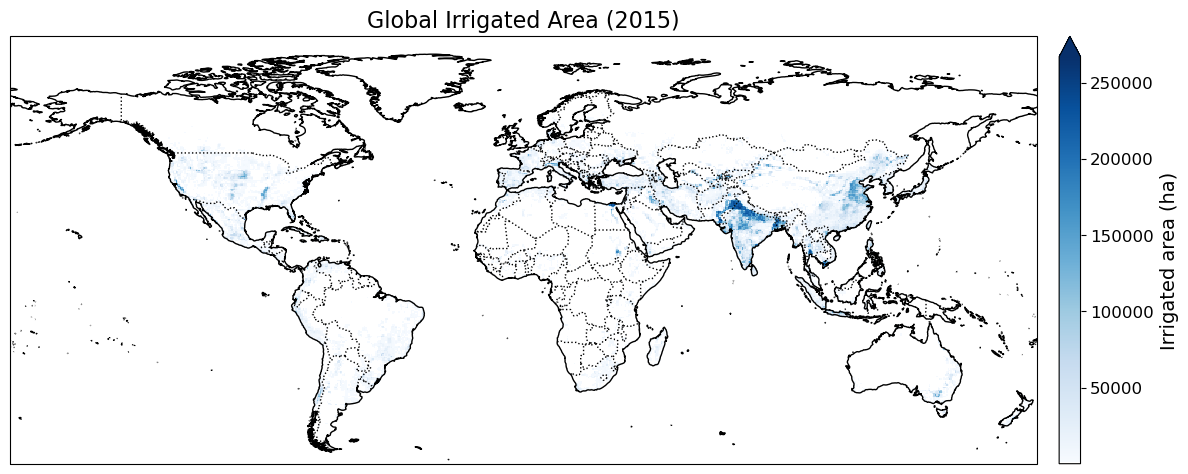

In [8]:
lat_min, lat_max = -60, 90
lon_min, lon_max = -182, 180

# Mask zero values
masked_aei = aei_coarse.where(aei_coarse > 0)

# Custom colormap: map NaNs to white
cmap = plt.cm.Blues
new_cmap = mcolors.ListedColormap(['white'] + [cmap(i) for i in range(1, cmap.N)])

# Plot setup
fig, ax = plt.subplots(
    1, 1,
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Plotting
mesh = ax.pcolormesh(
    masked_aei["lon"],
    masked_aei["lat"],
    masked_aei,
    transform=ccrs.PlateCarree(),
    cmap=new_cmap,
    shading="auto"
)

# Features
ax.add_feature(cfeature.COASTLINE.with_scale("50m"))
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":")
ax.set_title("Global Irrigated Area (2015)", fontsize=16)
ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)
ax.tick_params(labelsize=12)

# Colorbar (adjusted)
cbar = fig.colorbar(
    mesh,
    ax=ax,
    orientation="vertical",
    pad=0.02,
    fraction=0.035,
    shrink=0.75, 
    extend='max'
)
cbar.set_label("Irrigated area (ha)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

In [9]:
# compute the deltas between adjacent grid‐centers
dlat = float(aei_coarse['lat'].diff('lat').mean())
dlon = float(aei_coarse['lon'].diff('lon').mean())

print(f"Coarse resolution: {dlon:.3f}° longitude × {dlat:.3f}° latitude")

Coarse resolution: 0.500° longitude × 0.500° latitude


In [10]:
print(aei2015.where(aei2015 > 0).sum().item())
print(aei_coarse.where(aei_coarse > 0).sum().item())

329539844.72370505
329539844.723705


In [11]:
# def ha_to_sq_km(hectares):
#     return hectares * 0.01

# # Convert crop areas
# aei_sq_km = ha_to_sq_km(aei_coarse)
# aei_sq_km.where(aei_sq_km > 0).sum().item()

In [12]:
cropland_0p5 = xr.open_dataset('/home/madhulika.gurazada/paper2/Code/corrected_code/Code_to_use/correct_code/cropland_0p5_data.nc')
cropland_0p5.where(cropland_0p5['Band1'] > 0)
total_cropland = cropland_0p5

In [13]:
# Fractional cropland (0–100%) → convert to 0–1
cropland_fraction = total_cropland['Band1'].where(total_cropland['Band1'] > 0) / 100.0

# Convert degrees to radians for latitude
lat_rad = np.deg2rad(cropland_fraction['lat'])

# Earth's radius (km)
R = 6371

# Grid cell area (lat-dependent, same for all longitudes)
dlat = dlon = np.deg2rad(0.5)  # resolution in radians
grid_area_1d = (R**2) * dlat * dlon * np.cos(lat_rad)

# Expand to 2D to match shape of cropland_fraction
grid_area_2d = xr.DataArray(
    np.repeat(grid_area_1d.values[:, np.newaxis], len(cropland_fraction['lon']), axis=1),
    coords=[cropland_fraction['lat'], cropland_fraction['lon']],
    dims=['lat', 'lon']
)

# make grid area in hectares instead of km²
grid_area_2d_ha = grid_area_2d * 100

# Compute cropland area per cell and sum
total_cropland_km2 = (cropland_fraction * grid_area_2d).sum(skipna=True).item()

print(f"Total Cropland Area (km²): {total_cropland_km2:.2f}")

total_cropland_ha = (cropland_fraction * grid_area_2d_ha).sum(skipna=True).item()

print(f"Total Cropland Area: {total_cropland_ha:,.0f} ha")

Total Cropland Area (km²): 17102392.00
Total Cropland Area: 1,710,239,104 ha


In [14]:
total_cropland_km2 = cropland_fraction * grid_area_2d
total_cropland_km2

<xarray.DataArray (lat: 360, lon: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * lon      (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75

In [15]:
total_cropland_ha = cropland_fraction * grid_area_2d_ha
total_cropland_ha

<xarray.DataArray (lat: 360, lon: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * lon      (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75

In [16]:
aei_matched = aei_coarse.reindex_like(total_cropland_ha, method="nearest")
rainfed_ha  = total_cropland_ha - aei_matched
rainfed_ha

<xarray.DataArray (lat: 360, lon: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lon      (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75

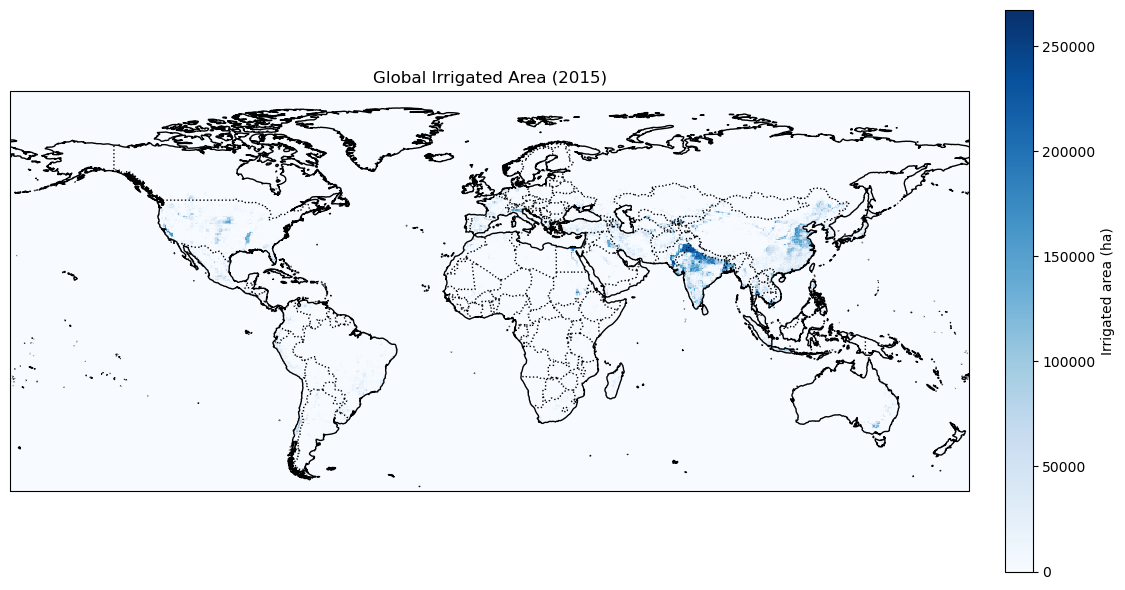

In [17]:
lat_min, lat_max = -60, 90
lon_min, lon_max = -182, 180

# aei2015: DataArray with dims ('latitude','longitude')
fig, ax = plt.subplots(
    1, 1,
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# use a blue‐based colormap
mesh = ax.pcolormesh(
    aei_matched["lon"],
    aei_matched["lat"],
    aei_matched,
    transform=ccrs.PlateCarree(),
    cmap="Blues",
    shading="auto"
)

ax.add_feature(cfeature.COASTLINE.with_scale("50m"))
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":")
ax.set_title("Global Irrigated Area (2015)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

cbar = fig.colorbar(
    mesh,
    ax=ax,
    orientation="vertical",
    pad=0.03,
    label="Irrigated area (ha)"
)

plt.tight_layout()
plt.show()

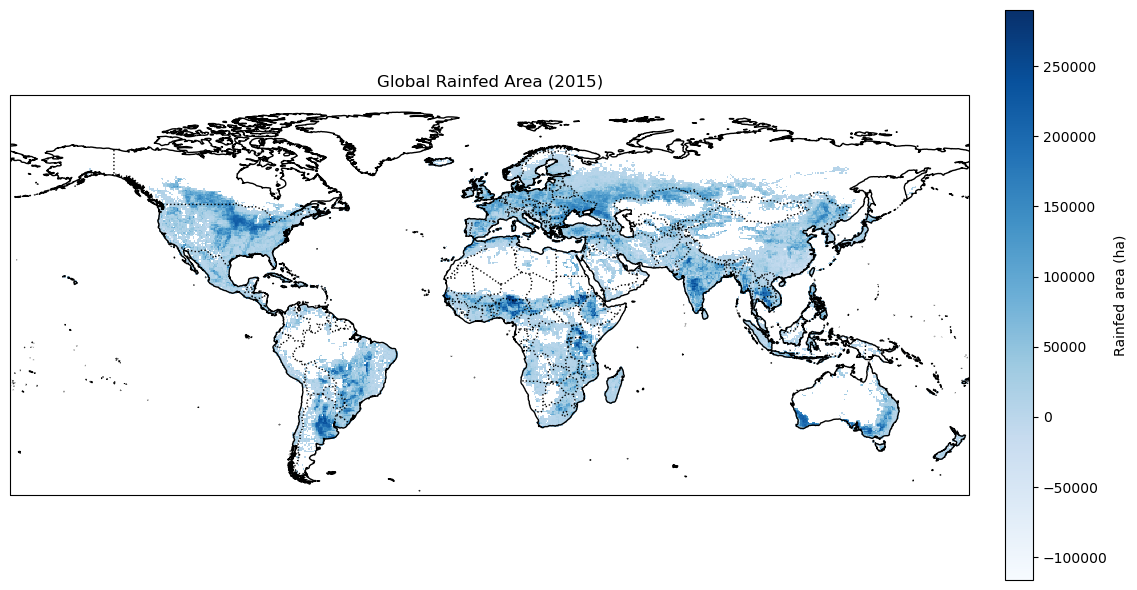

In [18]:
lat_min, lat_max = -60, 90
lon_min, lon_max = -182, 180

# aei2015: DataArray with dims ('latitude','longitude')
fig, ax = plt.subplots(
    1, 1,
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# use a blue‐based colormap
mesh = ax.pcolormesh(
    rainfed_ha["lon"],
    rainfed_ha["lat"],
    rainfed_ha,
    transform=ccrs.PlateCarree(),
    cmap="Blues",
    shading="auto"
)

ax.add_feature(cfeature.COASTLINE.with_scale("50m"))
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":")
ax.set_title("Global Rainfed Area (2015)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

cbar = fig.colorbar(
    mesh,
    ax=ax,
    orientation="vertical",
    pad=0.03,
    label="Rainfed area (ha)"
)

plt.tight_layout()
plt.show()

In [19]:
aei_matched.sum().item()

329539844.723705

In [20]:
rainfed_ha.sum().item()

1382396064.3697162

In [21]:
aei_matched.to_netcdf("/home/madhulika.gurazada/paper2/Data/irrigated_rainfed/irrigatedarea2015.nc")
rainfed_ha.to_netcdf("/home/madhulika.gurazada/paper2/Data/irrigated_rainfed/rainfedarea2015.nc")

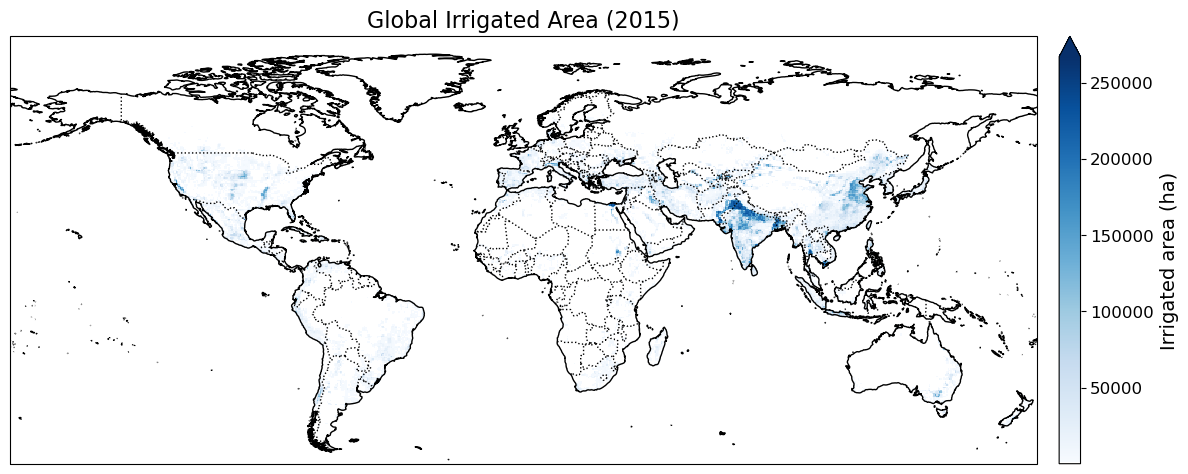

In [22]:
lat_min, lat_max = -60, 90
lon_min, lon_max = -182, 180

# Mask zero values
masked_aei = aei_matched.where(aei_matched > 0)

# Custom colormap: map NaNs to white
cmap = plt.cm.Blues
new_cmap = mcolors.ListedColormap(['white'] + [cmap(i) for i in range(1, cmap.N)])

# Plot setup
fig, ax = plt.subplots(
    1, 1,
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Plotting
mesh = ax.pcolormesh(
    masked_aei["lon"],
    masked_aei["lat"],
    masked_aei,
    transform=ccrs.PlateCarree(),
    cmap=new_cmap,
    shading="auto"
)

# Features
ax.add_feature(cfeature.COASTLINE.with_scale("50m"))
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":")
ax.set_title("Global Irrigated Area (2015)", fontsize=16)
ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)
ax.tick_params(labelsize=12)

# Colorbar (adjusted)
cbar = fig.colorbar(
    mesh,
    ax=ax,
    orientation="vertical",
    pad=0.02,
    fraction=0.035,
    shrink=0.75, 
    extend='max'
)
cbar.set_label("Irrigated area (ha)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

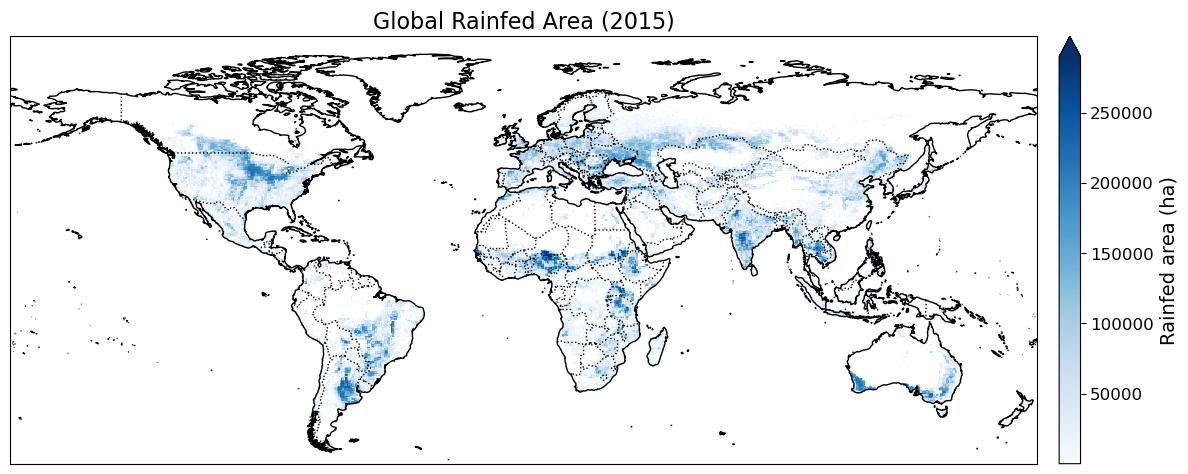

In [23]:
lat_min, lat_max = -60, 90
lon_min, lon_max = -182, 180

# Mask out zero or negative values
masked_rainfed = rainfed_ha.where(rainfed_ha > 0)

# Create a new colormap with white for zero/masked
base_cmap = plt.cm.Blues
custom_cmap = mcolors.ListedColormap(['white'] + [base_cmap(i) for i in range(1, base_cmap.N)])

# Plot setup
fig, ax = plt.subplots(
    1, 1,
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Plot with custom colormap
mesh = ax.pcolormesh(
    masked_rainfed["lon"],
    masked_rainfed["lat"],
    masked_rainfed,
    transform=ccrs.PlateCarree(),
    cmap=custom_cmap,
    shading="auto"
)

# Add map features
ax.add_feature(cfeature.COASTLINE.with_scale("50m"))
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":")
ax.set_title("Global Rainfed Area (2015)", fontsize=16)
ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)
ax.tick_params(labelsize=12)

# Colorbar (adjusted)
cbar = fig.colorbar(
    mesh,
    ax=ax,
    orientation="vertical",
    pad=0.02,
    fraction=0.035,
    shrink=0.75, 
    extend='max'
)
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Rainfed area (ha)", fontsize=14)

plt.tight_layout()
plt.show()